## Generate Some of the Initial Simple Strategies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from quant_slc_hedging.data_model import (
    LoanModelInputs,
    SalaryModelInputs,
    SalaryGrowthType,
    salary_growth_amounts
)
from quant_slc_hedging.salary import SalaryModel
from quant_slc_hedging.loan import LoanModel
from quant_slc_hedging.strategies.min_repayment import MinRepaymentStrategy
from quant_slc_hedging.strategies.fixed_pct_repayment import FixedPctRepaymentStrategy
from quant_slc_hedging.simulation import SimulationHandler


In [2]:
N_PATHS = 10_000
YEARS_REMAINING = 30
OBSERVATIONS = YEARS_REMAINING * 12
SEED = 1234

STARTING_SALARY = 35_000
INITIAL_LOAN = 45_000

OVERPAYMENT_PCTS = [0.00, 0.05, 0.10, 0.25, 0.50, 1.00]

loan_config = LoanModelInputs(
    initial_loan_balance=INITIAL_LOAN,
    remaining_loan_term_months=OBSERVATIONS,
)


In [3]:
results = {}

for growth_type in salary_growth_amounts.keys():
    salary_config = SalaryModelInputs(
        starting_salary=STARTING_SALARY,
        salary_growth_dist=SalaryGrowthType(growth_type=growth_type)
    )

    for pct in OVERPAYMENT_PCTS:
        if pct == 0.0:
            strategy = MinRepaymentStrategy()
            strategy_name = "Minimum"
        else:
            strategy = FixedPctRepaymentStrategy(
                fixed_excess_pct=pct,
                repayment_threshold=loan_config.repayment_threshold,
            )
            strategy_name = f"{pct:.0%} excess"

        sim = SimulationHandler(
            salary_config=salary_config,
            loan_config=loan_config,
            strategy=strategy,
            n_paths=N_PATHS,
            observations=OBSERVATIONS,
            seed=SEED,
        )

        results[(growth_type, strategy_name)] = sim.run_simulation()


Sim finished
Sim finished
Sim finished
Sim finished
Sim finished
Sim finished
Sim finished
Sim finished
Sim finished
Sim finished
Sim finished
Sim finished
Sim finished
Sim finished
Sim finished
Sim finished
Sim finished
Sim finished


In [4]:
def first_zero_month(loan_balance: np.ndarray) -> np.ndarray:
    repaid = np.any(loan_balance == 0, axis=1)
    month = np.full(loan_balance.shape[0], np.nan)
    month[repaid] = np.argmax(loan_balance[repaid] == 0, axis=1)
    return month


metrics = []

for (growth_type, strategy_name), result in results.items():
    salary_paths = result.salary_paths
    loan_result = result.loan_result

    loan_balance = loan_result.loan_balance
    repayment_month = first_zero_month(loan_balance)

    metrics.append({
        "Growth Type": growth_type,
        "Strategy": strategy_name,
        "Median Final Salary": np.median(salary_paths[:, -1]),
        "Median Final Loan": np.median(loan_balance[:, -1]),
        "Mean Final Loan": np.mean(loan_balance[:, -1]),
        "Probability Repaid": np.mean(~np.isnan(repayment_month)),
        "Median Payoff Year": np.nanmedian(repayment_month / 12),
        "Median Total Interest": np.median(loan_result.interest_accrued.sum(axis=1)),
        "Median Mandatory Repayment": np.median(loan_result.base_repayment.sum(axis=1)),
        "Median Voluntary Repayment": np.median(loan_result.additional_repayment.sum(axis=1)),
    })

metric_panel = pd.DataFrame(metrics)
metric_panel.sort_values(["Growth Type", "Strategy"])


,Growth Type,Strategy,Median Final Salary,Median Final Loan,Mean Final Loan,Probability Repaid,Median Payoff Year,Median Total Interest,Median Mandatory Repayment,Median Voluntary Repayment
14,High,10% excess,498102.311440,0.000000,57.715624,0.9979,11.083333,19594.545590,394776.200107,4.386402e+05
17,High,100% excess,498102.311440,0.000000,0.000000,1.0000,3.750000,4432.685127,394776.200107,4.386402e+06
15,High,25% excess,498102.311440,0.000000,0.285716,0.9999,7.833333,11953.828686,394776.200107,1.096601e+06
13,High,5% excess,498102.311440,0.000000,245.135340,0.9930,13.250000,25336.007108,394776.200107,2.193201e+05
16,High,50% excess,498102.311440,0.000000,0.000000,1.0000,5.500000,7453.020744,394776.200107,2.193201e+06
12,High,Minimum,498102.311440,0.000000,1347.578866,0.9686,16.833333,37028.769938,394776.200107,0.000000e+00
2,Low,10% excess,45775.805751,46203.424281,44074.591560,0.2030,25.083333,60611.899737,29204.053702,3.244895e+04
5,Low,100% excess,45775.805751,0.000000,1533.677557,0.9605,6.916667,6644.003012,29204.053702,3.244895e+05
3,Low,25% excess,45775.805751,0.000000,14307.938656,0.6717,18.500000,27984.492907,29204.053702,8.112237e+04
1,Low,5% excess,45775.805751,76575.831206,70250.054964,0.0336,26.958333,73869.996732,29204.053702,1.622447e+04


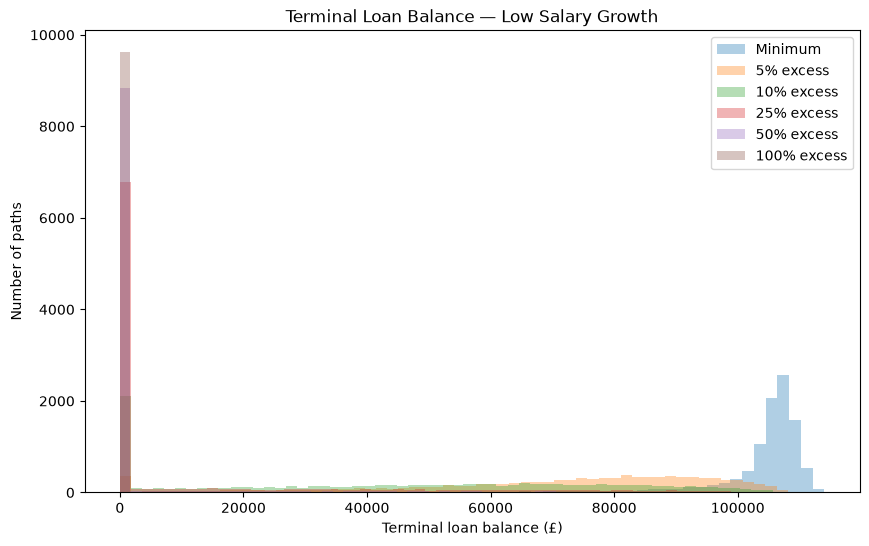

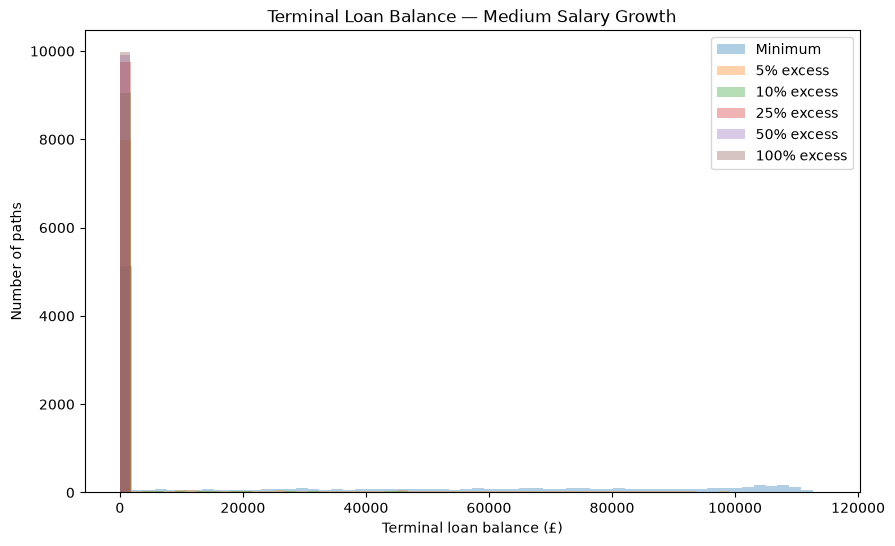

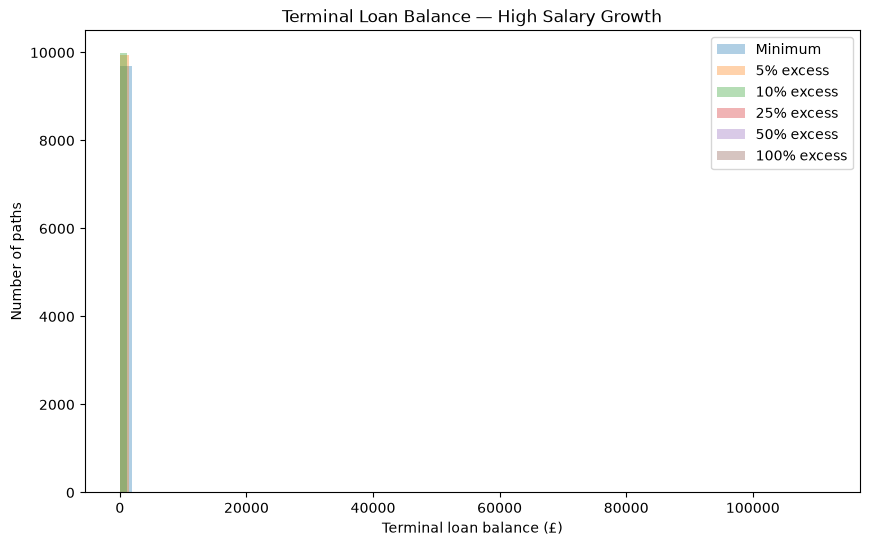

In [6]:
for growth_type in salary_growth_amounts.keys():
    plt.figure(figsize=(10, 6))

    for strategy_name in ["Minimum", "5% excess", "10% excess", "25% excess", "50% excess", "100% excess"]:
        result = results[(growth_type, strategy_name)]
        plt.hist(
            result.loan_result.loan_balance[:, -1],
            bins=60,
            alpha=0.35,
            label=strategy_name,
        )

    plt.xlabel("Terminal loan balance (£)")
    plt.ylabel("Number of paths")
    plt.title(f"Terminal Loan Balance — {growth_type} Salary Growth")
    plt.legend()
    plt.show()


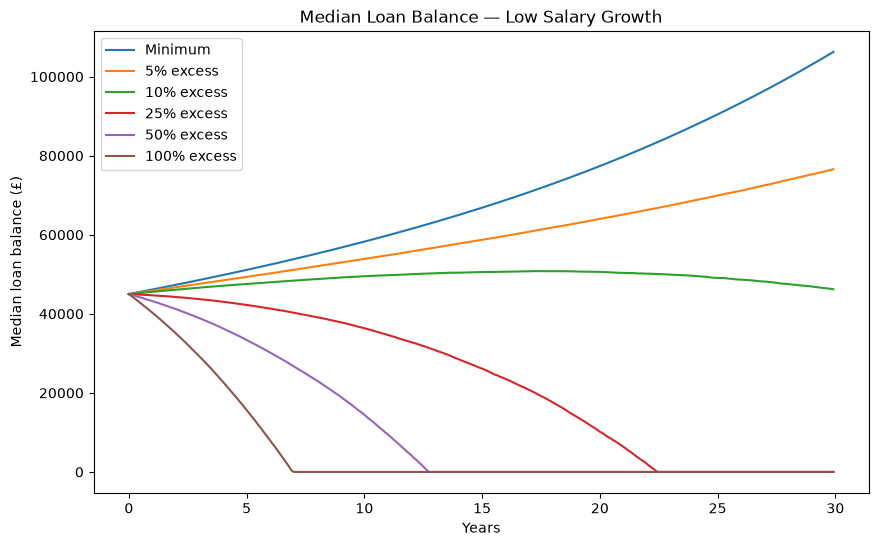

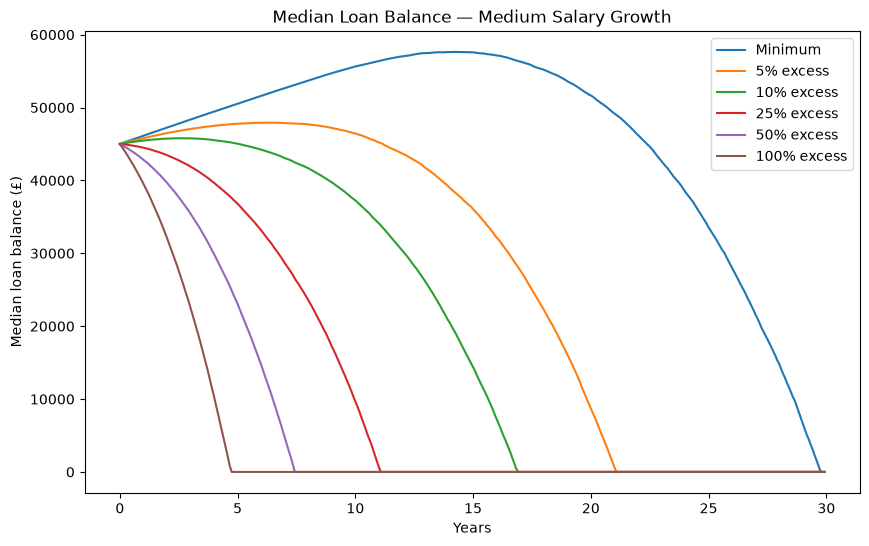

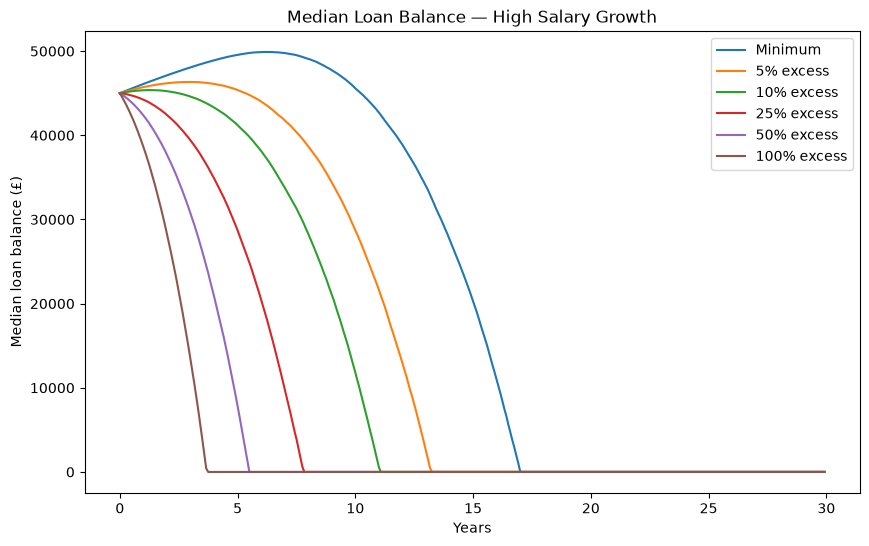

In [10]:
months = np.arange(OBSERVATIONS)

for growth_type in salary_growth_amounts.keys():
    plt.figure(figsize=(10, 6))

    for strategy_name in ["Minimum", "5% excess", "10% excess", "25% excess", "50% excess", "100% excess"]:
        result = results[(growth_type, strategy_name)]
        median_balance = np.median(result.loan_result.loan_balance, axis=0)
        plt.plot(months / 12, median_balance, label=strategy_name)

    plt.xlabel("Years")
    plt.ylabel("Median loan balance (£)")
    plt.title(f"Median Loan Balance — {growth_type} Salary Growth")
    plt.legend()
    plt.show()
